# Delhivery Logistic Pipeline Analysis

The company wants to understand and process the data coming out of data engineering pipelines:
- Clean, sanitize and manipulate data to get useful features out of raw fields
- Make sense out of the raw data and help the data science team to build forecasting models on it

## Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import levene
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
import warnings

warnings.simplefilter('ignore')

In [2]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/551/original/delhivery_data.csv?1642751181')

In [3]:
pd.set_option('Display.max_columns', None)

In [4]:
# Raw data shape
df.shape

(144867, 24)

Raw Dataset contains 144867 rows and 24 columns

## Data Preprocessing

In [5]:
# Null values

print(df.isna().sum())

df.isna().sum().sum() * 100 / len(df)

data                                0
trip_creation_time                  0
route_schedule_uuid                 0
route_type                          0
trip_uuid                           0
source_center                       0
source_name                       293
destination_center                  0
destination_name                  261
od_start_time                       0
od_end_time                         0
start_scan_to_end_scan              0
is_cutoff                           0
cutoff_factor                       0
cutoff_timestamp                    0
actual_distance_to_destination      0
actual_time                         0
osrm_time                           0
osrm_distance                       0
factor                              0
segment_actual_time                 0
segment_osrm_time                   0
segment_osrm_distance               0
segment_factor                      0
dtype: int64


np.float64(0.3824197367240296)

Source center and Destination center have the missing names which is only 0.38% of the dataset. 554 rows are has been removed.

In [6]:
# Duplicated rows

df.duplicated().sum()

np.int64(0)

In [7]:
# Trip-Segment wise data

df = df.groupby(
    ['trip_uuid', 'trip_creation_time', 'route_schedule_uuid', 'route_type', 'source_center', 'source_name', 'destination_center', 'destination_name', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan']).agg({'segment_actual_time': 'sum', 'segment_osrm_time': 'sum', 'actual_distance_to_destination': 'max', 'segment_osrm_distance': 'sum'}).reset_index().round(2)

In [8]:
# Timestamps converted

df['trip_creation_time'] = pd.to_datetime(df['trip_creation_time'])
df['od_start_time'] = pd.to_datetime(df['od_start_time'])
df['od_end_time'] = pd.to_datetime(df['od_end_time'])

In [9]:
# States extracted from source and destination names

df['source_state'] = df['source_name'].str.split(r'[()]', expand=True)[1]
df['destination_state'] = df['destination_name'].str.split(r'[()]', expand=True)[1]

In [10]:
# Inter-State and Intra-State column

df['trip_type'] = 'Intra-state'

df.loc[df['source_state'] != df['destination_state'], 'trip_type'] = 'Inter-state'

In [11]:
# Time of Day column

df['time_of_day'] = df['od_start_time'].dt.hour.apply(
    lambda x: 'Early Morning' if 4 <= x <= 8
    else 'Morning' if 9 <= x <= 12
    else 'Afternoon' if 13 <= x <= 16
    else 'Evening' if 17 <= x <= 18
    else 'Late Evening' if 19 <= x <= 21
    else 'Night'
)

In [12]:
# Columns renamed

df = df.rename(columns={'route_type': 'shipment_type', 'trip_type': 'segment_route_type'})

In [13]:
# Actual and OSRM differences

df['time_diff'] = df['segment_actual_time'] - df['segment_osrm_time']
df['distance_diff'] = df['segment_osrm_distance'] - df['actual_distance_to_destination']

# Handling Time
df['handling_time'] = df['start_scan_to_end_scan'] - df['segment_actual_time']

In [14]:
# Columns re-arranged

df = df[['trip_uuid', 'trip_creation_time', 'time_of_day', 'route_schedule_uuid', 'shipment_type', 'source_center', 'source_name', 'source_state', 'destination_center', 'destination_name', 'destination_state', 'segment_route_type', 'od_start_time', 'od_end_time', 'start_scan_to_end_scan', 'segment_actual_time', 'segment_osrm_time', 'actual_distance_to_destination', 'segment_osrm_distance', 'time_diff', 'distance_diff', 'handling_time']]

In [15]:
# Shape of processed dataset

df.shape

(26223, 22)

Processed (segment wise) dataset has 26223 rows and 22 columns.

## Data Analysis

In [16]:
# Trip count

df['trip_uuid'].nunique()

14787

In [17]:
# Dasaset time range

min(df['od_start_time']) , max(df['od_end_time'])

(Timestamp('2018-09-12 00:00:16.535741'),
 Timestamp('2018-10-08 03:00:24.353479'))

Dataset ranges between time period 12 Sep 2018 - 8 Oct 2018

In [18]:
# Trip segments

len(df)

26223

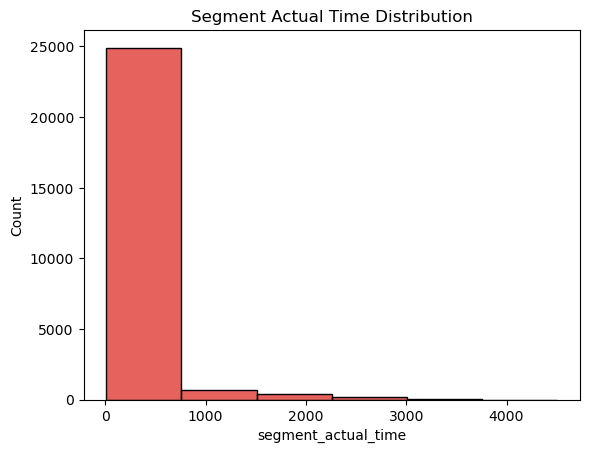

In [19]:
# Segment actual time distribution

sns.histplot(data=df, x='segment_actual_time', color='#de2d26' , bins=6)
plt.title('Segment Actual Time Distribution')
plt.show()

Some segments deliveries take long time than the typical segment trips, which range between (0 - 700 minutes).

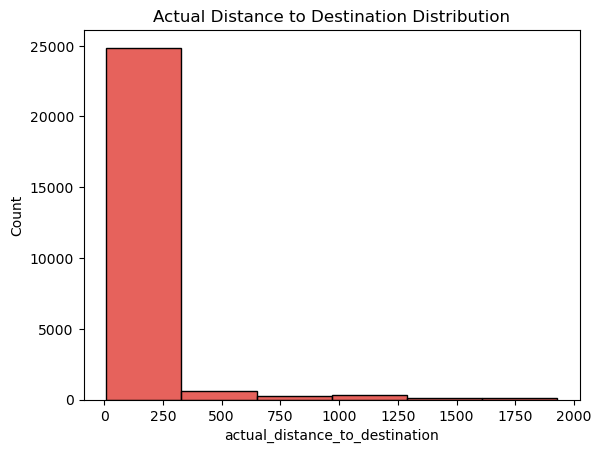

In [20]:
# Segment actual time distribution

sns.histplot(data=df, x='actual_distance_to_destination', color='#de2d26' , bins=6)
plt.title('Actual Distance to Destination Distribution')
plt.show()

Usually segment trip are under 270KM, whereas some trips are of longer distance. 

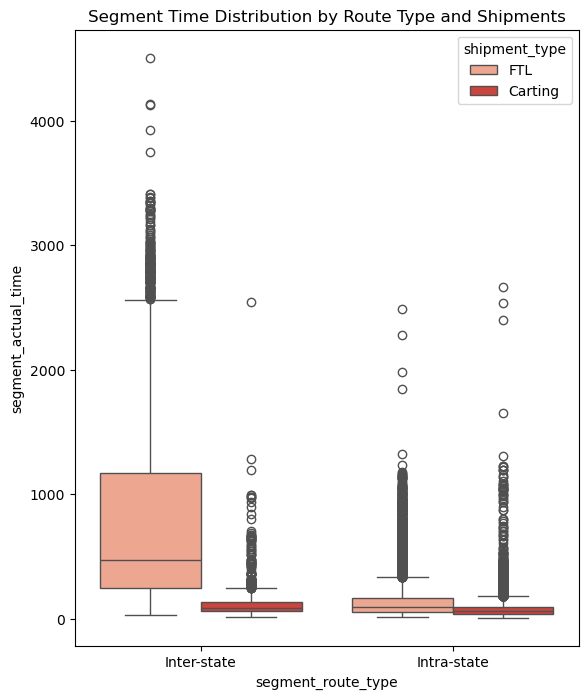

In [21]:
# Segment time by route type and shipment type

plt.figure(figsize=(6.5, 8))
sns.boxplot(data= df, x='segment_route_type', y='segment_actual_time', hue='shipment_type', palette='Reds')
plt.title('Segment Time Distribution by Route Type and Shipments')
plt.show()

Full Truck Load deliveries usually take more time than Carting shipments. Most values are concentrated around median.

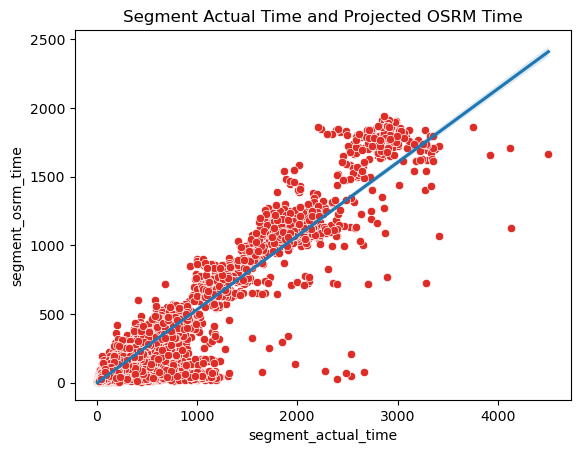

In [22]:
# Segment actual time and Osrm time 

sns.scatterplot(data=df, x='segment_actual_time', y='segment_osrm_time', c='#de2d26')
sns.regplot(data=df, x='segment_actual_time', y='segment_osrm_time', scatter=False)
plt.title('Segment Actual Time and Projected OSRM Time')
plt.show()

**Hypothesis Test between segment actual time and projected time**

Null Hypothesis (Ho) :- Segment actual time and routing machine projected time are NOT significantly different.  
Alternate Hypothesis (Ha) :- Segment actual time and routing machine projected time ARE significantly different.

Mathematically:-  
Ho => mean(segment_actual_time) = mean(segment_osrm_time)  
Ha => mean(segment_actual_time) != mean(segment_osrm_time)

In [23]:
# Statistical analysis between segment actual time and segment osrm time.

test_statistics , pvalue = ttest_ind(df['segment_actual_time'], df['segment_osrm_time'])
print(test_statistics, pvalue)
print(f'segment actual time mean: {df['segment_actual_time'].mean().round(2)}, segment osrm time mean: {df['segment_osrm_time'].mean().round(2)}')

# Level of Significance 5%
if pvalue < 0.05:
    print('reject Ho')
else:
    print('failed to reject Ho')

35.885763306669844 1.231651595641894e-278
segment actual time mean: 199.09, segment osrm time mean: 101.79
reject Ho


Two sample T Test shows statistically significant difference between segment actual time and segment projected time. Average segment actual time is substantially higher than the projected osrm time, leading to reject the null hypothesis.

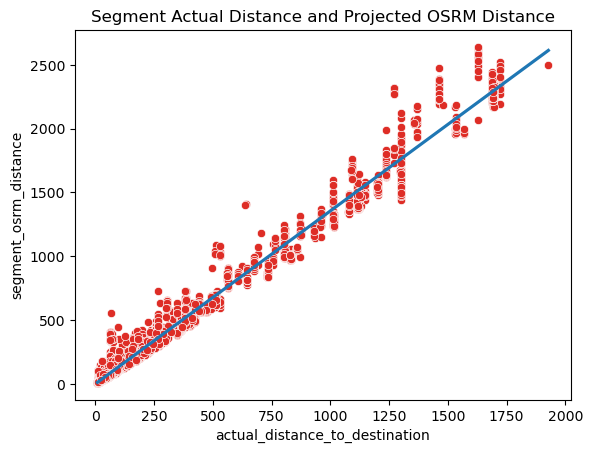

In [24]:
# Segment actual distance and Osrm distance 

sns.scatterplot(data=df, x='actual_distance_to_destination', y='segment_osrm_distance', c='#de2d26')
sns.regplot(data=df, x='actual_distance_to_destination', y='segment_osrm_distance', scatter=False)
plt.title('Segment Actual Distance and Projected OSRM Distance')
plt.show()

**Hypothesis Test between segment distance and projected osrm distance**  

Null Hypothesis (Ho) :- Segment actual distance and routing machine projected distance are NOT significantly different.  
Alternate Hypothesis (Ha) :- Segment actual distance and routing machine projected distance ARE significantly different.

Mathematically:-  
Ho => mean(actual_distance_to_destination) = mean(segment_osrm_distance)  
Ha => mean(actual_distance_to_destination) != mean(segment_osrm_distance)

In [25]:
# Statistical analysis between segment actual distance and segment osrm distance.

test_statistics , pvalue = ttest_ind(df['actual_distance_to_destination'], df['segment_osrm_distance'])
print(test_statistics, pvalue)
print(f'segment actual distance mean: {df['actual_distance_to_destination'].mean().round(2)}, segment osrm distance mean: {df['segment_osrm_distance'].mean().round(2)}')

# Level of Significance 5%
if pvalue < 0.05:
    print('reject Ho')
else:
    print('failed to reject Ho')

-15.009377598044662 8.130768960712487e-51
segment actual distance mean: 92.64, segment osrm distance mean: 125.58
reject Ho


Two sample T Test shows statistically significant difference between segment actual distance and segment projected distance. Average segment actual distance is substantially lower than the projected osrm distance, leading to reject the null hypothesis.

In [26]:
# Most popular routes

df.groupby(['route_schedule_uuid', 'source_name', 'destination_name']).size().sort_values(ascending=False)[:10]

route_schedule_uuid                                  source_name                           destination_name                    
thanos::sroute:a16bfa03-3462-4bce-9c82-5784c7d315e6  LowerParel_CP (Maharashtra)           Mumbai_Chndivli_PC (Maharashtra)        53
thanos::sroute:8e6cd941-adb5-4f66-b44f-84938f5fca03  Mumbai_Chndivli_PC (Maharashtra)      Bhiwandi_Mankoli_HB (Maharashtra)       46
thanos::sroute:c736b86f-5c1d-4497-832c-876db4c1a518  Gurgaon_Begumpur_CP (Haryana)         Gurgaon_Bilaspur_P (Haryana)            43
thanos::sroute:5f8fb6cf-814a-426f-b2c9-8665b605d343  Noida_Sector02_C (Uttar Pradesh)      Del_Okhla_PC (Delhi)                    40
thanos::sroute:3a78a6e9-ef19-43ae-832e-e4a3868eb32d  Hyderabad_Alwal_L (Telangana)         Hyderabad_Shamshbd_H (Telangana)        39
thanos::sroute:5dd1132a-b8a0-4b55-9df1-08937607bb65  Mumbai Hub (Maharashtra)              Mumbai_Sanpada_I (Maharashtra)          37
thanos::sroute:b743d024-a50a-40a4-8ffd-e3b420b7534e  Mumbai Hub (Mah

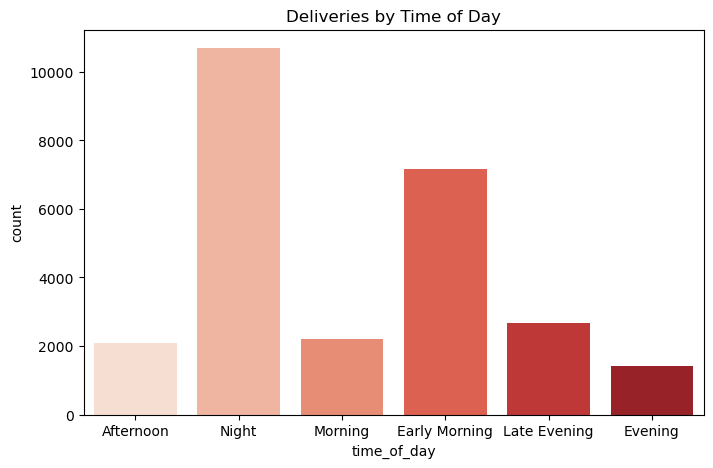

In [27]:
# Deliveries by Time of Day

plt.figure(figsize=(8, 5))
sns.countplot(x=df['time_of_day'], palette='Reds')
plt.title('Deliveries by Time of Day')
plt.show()

Driver prefer starting trip at Night or in the early morning to avoid traffic.

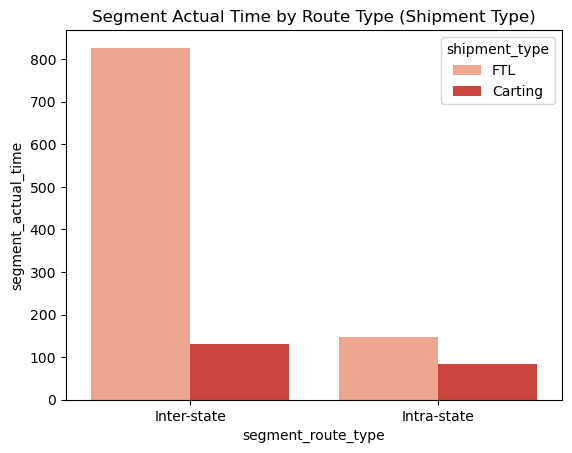

In [28]:
# Segment actual time by route type and shipment

sns.barplot(data=df, x='segment_route_type', y='segment_actual_time', hue='shipment_type', palette='Reds', estimator='mean', errorbar=None)
plt.title('Segment Actual Time by Route Type (Shipment Type)')
plt.show()

**Hypothesis test for actual segment time taken between shipment types for Intra-state segments**  

Null Hypothesis (Ho) :- Actual segment time for FTL shipment and Carting shipment in Intra-state are NOT significantly different.  
Alternate Hypothesis (Ha) :- Actual segment time for FTL shipment and Carting shipment in Intra-state ARE significantly different.  

Mathematically:-  
Ho => mean(segment_actual_time/FTL shipments) = mean(segment_actual_time/Carting shipments)  
Ha => mean(segment_actual_time/FTL shipments) != mean(segment_actual_time/Carting shipments)

In [29]:
# Hypothesis test for actual segment time between shipment types for intra-state deliveries

intra_state_df = df[df['segment_route_type'] == 'Intra-state']
ftl_df = intra_state_df[intra_state_df['shipment_type'] == 'FTL']['segment_actual_time']
carting_df = intra_state_df[intra_state_df['shipment_type'] == 'Carting']['segment_actual_time'].sample(10736)

test_stats, pvalue = ttest_ind(ftl_df, carting_df)
print(test_stats, pvalue)
print(f'segment actual time mean for FTL shipment in Intra-state route: {ftl_df.mean().round(2)}, segment actual time mean for carting shipment in Intra-state route: {carting_df.mean().round(2)}')

# Level of significance is 5%
if pvalue <= 0.05:
    print('reject Ho')
else:
    print('failed to reject Ho')

34.76578529326761 1.0880956150146695e-257
segment actual time mean for FTL shipment in Intra-state route: 147.26, segment actual time mean for carting shipment in Intra-state route: 84.21
reject Ho


Two sample T Test shows statistical significant difference between segment actual time for FTL shipment and carting shipment. Average segment actual time for FTL shipment type is substantially higher than segment actual time for carting shipments.

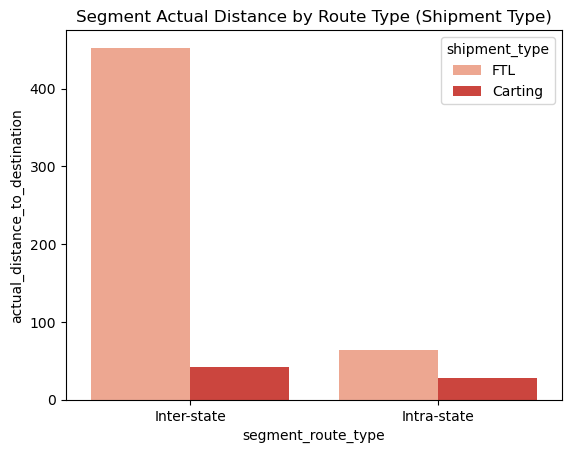

In [30]:
# Segment actual distance by route type and shipment

sns.barplot(data=df, x='segment_route_type', y='actual_distance_to_destination', hue='shipment_type', palette='Reds', estimator='mean', errorbar=None)
plt.title('Segment Actual Distance by Route Type (Shipment Type)')
plt.show()

**Hypothesis test for actual segment distance between shipment types for Intra-state segments**  

Null Hypothesis (Ho) :- Actual segment distance for FTL shipment and Carting shipment in Intra-state are NOT significantly different.  
Alternate Hypothesis (Ha) :- Actual segment distance for FTL shipment and Carting shipment in Intra-state ARE significantly different.  

Mathematically:-  
Ho => mean(actual_distance_to_destination/FTL shipments) = mean(actual_distance_to_destination/Carting shipments)  
Ha => mean(actual_distance_to_destination/FTL shipments) != mean(actual_distance_to_destination/Carting shipments)

In [31]:
# Hypothesis test for segment actual distance between shipment types for intra-state deliveries

ftl_df = intra_state_df[intra_state_df['shipment_type'] == 'FTL']['actual_distance_to_destination']
carting_df = intra_state_df[intra_state_df['shipment_type'] == 'Carting']['actual_distance_to_destination'].sample(10736)

test_stats, pvalue = ttest_ind(ftl_df, carting_df)
print(test_stats, pvalue)
print(f'segment actual distance mean for FTL shipment in Intra-state route: {ftl_df.mean().round(2)}, segment actual distance mean for carting shipment in Intra-state route: {carting_df.mean().round(2)}')

# Level of significance is 5%
if pvalue <= 0.05:
    print('reject Ho')
else:
    print('failed to reject Ho')

62.83985421566683 0.0
segment actual distance mean for FTL shipment in Intra-state route: 63.6, segment actual distance mean for carting shipment in Intra-state route: 27.52
reject Ho


Two sample T Test shows statistical significant difference between segment actual distance for FTL shipment and carting shipment. Average segment actual distance for FTL shipment type is substantially higher than the average segment actual distance for carting shipments.

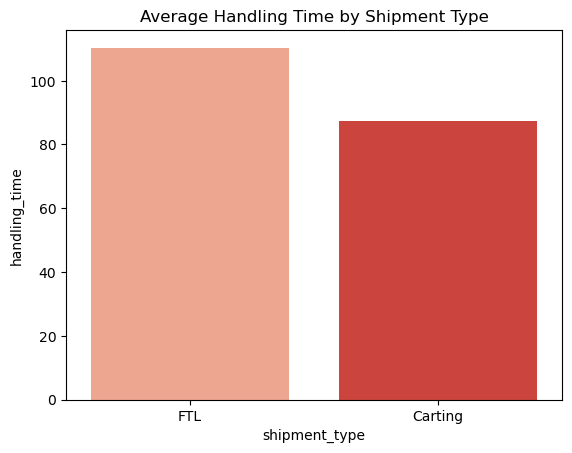

In [32]:
# Handling time by Shipment type

sns.barplot(data=df, x='shipment_type', y='handling_time', errorbar=None, estimator='mean', palette='Reds')
plt.title('Average Handling Time by Shipment Type')
plt.show()

**Hypothesis Test for Handling time between shipment types**  

Null Hypothesis (Ho) :- Average handling time taken by FTL shipment and Carting shipment are NOT significantly different.  
Alternate Hypothesis (Ha) :- Average handling time taken by FTL shipment and Carting shipment ARE significantly different.  

Mathematically:-  
Ho => mean(handling time/FTL shipment) = mean(handling time/Carting shipment)  
Ha => mean(handling time/FTL shipment) != mean(handling time/Carting shipment)

In [45]:
# Handling time taken by shipment types

ftl_df = df[df['shipment_type'] == 'FTL']['handling_time'].sample(12424)
carting_df = df[df['shipment_type'] == 'Carting']['handling_time']

test_stats, pvalue = mannwhitneyu(ftl_df, carting_df)
print(test_stats, pvalue)
print(f'Average handling time for FTL shipments: {ftl_df.mean().round(2)}, Average handling time for Carting shipments: {carting_df.mean().round(2)}')


# Level of Significance 5%
if pvalue < 0.05:
    print('reject Ho')
else:
    print('failed to reject Ho')

78695578.5 0.007262682790362569
Average handling time for FTL shipments: 110.43, Average handling time for Carting shipments: 87.33
reject Ho


Two sample T Test shows statistical significant difference between handling time for FTL shipment and carting shipment. Average segment handling time for FTL shipment type is substantially higher than the average segment handling time for carting shipments.

In [34]:
# Intra-state and Inter-state dataset

inter_df = df[df['segment_route_type'] == 'Inter-state']
intra_df = df[df['segment_route_type'] == 'Intra-state']

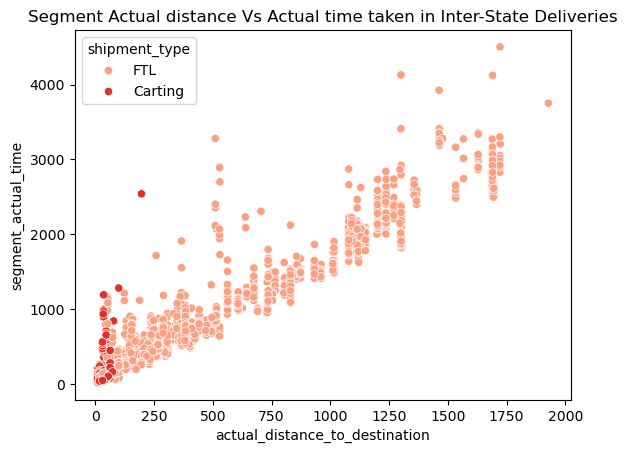

In [35]:
# Segment Actual Distance Vs Actual Time taken in Inter-state Deliveries

sns.scatterplot(data=inter_df, x='actual_distance_to_destination', y='segment_actual_time', hue='shipment_type', palette='Reds')
plt.title('Segment Actual distance Vs Actual time taken in Inter-State Deliveries')
plt.show()

In [36]:
# Correlation between Actual distance and actual time for Inter-state deliveries

corr_value , pvalue = spearmanr(inter_df['actual_distance_to_destination'], inter_df['segment_actual_time'])

print(f'Dataset is heavily skewed thatswhy spearman correlation is used. correlation value: {corr_value}')

Dataset is heavily skewed thatswhy spearman correlation is used. correlation value: 0.9445677577729477


- Carting shipments are within 250 km for Inter-state deliveries.
- FTL shipments show high variation.
- Distance and Time show strong correlation for inter-state deliveries.

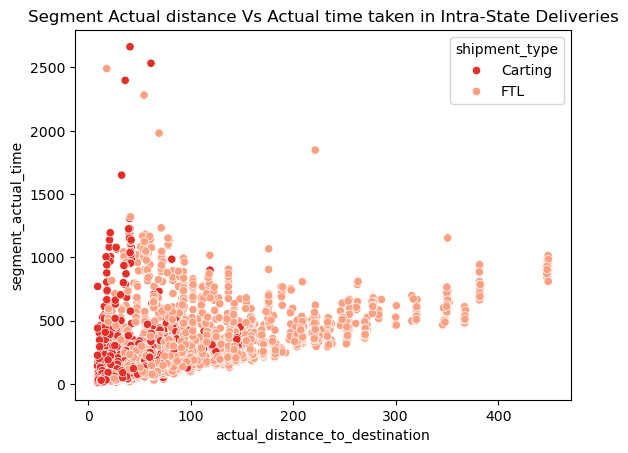

In [37]:
# Segment Actual Distance Vs Actual Time taken in Intra-state deliveries

sns.scatterplot(data=intra_df, x='actual_distance_to_destination', y='segment_actual_time', hue='shipment_type', palette='Reds_r')
plt.title('Segment Actual distance Vs Actual time taken in Intra-State Deliveries')
plt.show()

In [38]:
# Correlation between Actual distance and actual time for Intra-state deliveries

corr_value , pvalue = spearmanr(intra_df['actual_distance_to_destination'], intra_df['segment_actual_time'])

print(f'Dataset is heavily skewed thatswhy spearman correlation is used. correlation value: {corr_value}')

Dataset is heavily skewed thatswhy spearman correlation is used. correlation value: 0.749918488791377


- Shorter distance show more variation in delivery time.
- Distance and Time correlation for intra-state deliveries is weaker as compared to Inter-state deliveries correlation.

In [39]:
# Speed Column (KM/h)

df['vehicle_speed'] = df['actual_distance_to_destination'] / (df['segment_actual_time'] / 60)

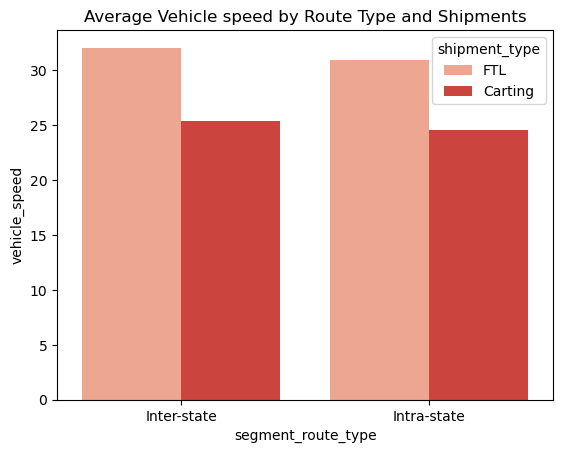

In [40]:
# Average vehicle speed by Route Type and Shipments

sns.barplot(data=df, x='segment_route_type', y='vehicle_speed', errorbar=None, hue='shipment_type', palette='Reds')
plt.title('Average Vehicle speed by Route Type and Shipments')
plt.show()

**Hypothesis test for average vehicle Speed for Inter-state carting deliveries and Intra-state carting deliveries**  

Null Hypothesis (Ho) :- Average speed for Inter-state carting deliveries and Intra-state carting deliveries are NOT significantly different.  
Alternate Hypothesis (Ha) :- Average speed for Inter-state carting deliveries and Intra-state carting deliveries ARE significantly different.  

Mathematically :-  
Ho => mean(vehicle_speed/Inter-state carting) = mean(vehicle_speed/Intra-state carting)  
Ha => mean(vehicle_speed/Inter-state carting) != mean(vehicle_speed/Intra-state carting)

In [41]:
# Average speed for carting vehicle in Inter-state and Intra-state deliveries

inter_carting_speed = df[(df['segment_route_type'] == 'Inter-state') & (df['shipment_type'] == 'Carting')]['vehicle_speed'].round(2)
intra_carting_speed = df[(df['segment_route_type'] == 'Intra-state') & (df['shipment_type'] == 'Carting')]['vehicle_speed'].round(2)

test_stats , pvalue = mannwhitneyu(inter_carting_speed, intra_carting_speed)
print('Mann-whitney U test performed', test_stats, pvalue)
print(f'average inter-state carting shipment speed: {inter_carting_speed.mean().round(2)}, average intra-state carting shipment speed: {intra_carting_speed.mean().round(2)}')

# Level of significance 5%
if pvalue < 0.1:
    print('reject Ho')
else:
    print('failed to reject Ho')

Mann-whitney U test performed 7436017.5 0.00012003552213449775
average inter-state carting shipment speed: 25.37, average intra-state carting shipment speed: 24.53
reject Ho


Mann-Whitney U Test shows that statistically average speed for inter-state carting shipments and intra-state carting shipments are significantly. <u> But Practically on seeing the results inter-state carting shipment vehicle speed is just slightly faster<u> .

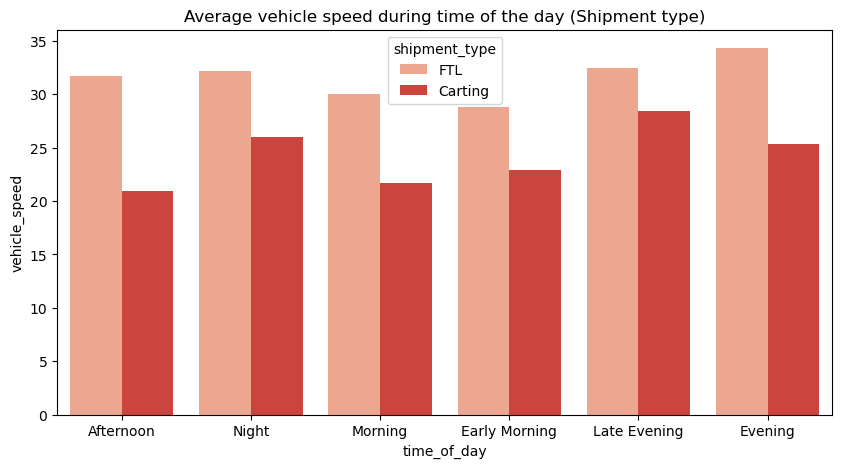

In [69]:
# Vehicle speed during time of day

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='time_of_day', y='vehicle_speed', errorbar=None, estimator='mean', hue='shipment_type', palette='Reds')
plt.title('Average vehicle speed during time of the day (Shipment type)')
plt.show()

Average speed for carting shipments are faster at Night and in the late evening.

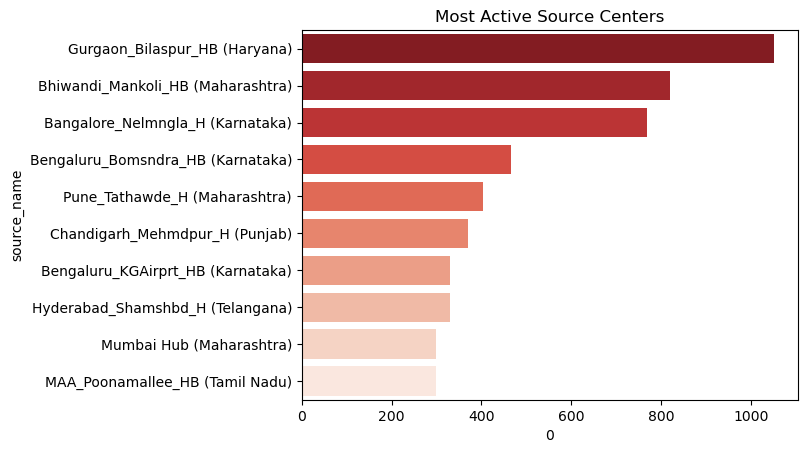

In [43]:
# Top 10 delivery source centers

sns.barplot(data=df.groupby('source_name').size().sort_values(ascending=False).reset_index()[:10], y='source_name', x=0, palette='Reds_r')
plt.title('Most Active Source Centers')
plt.show()

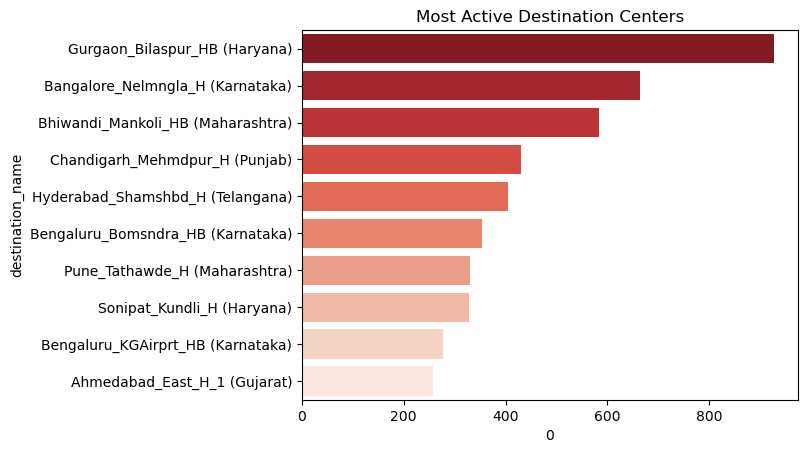

In [44]:
# Top 10 delivery destination centers

sns.barplot(data=df.groupby('destination_name').size().sort_values(ascending=False).reset_index()[:10], y='destination_name', x=0, palette='Reds_r')
plt.title('Most Active Destination Centers')
plt.show()

Most Active Delhivery centers are Gurgaon Bilaspur (Haryana) , Bangalore Nelmngla (Karnataka), Bhiwandi Mankoli (Maharastra)

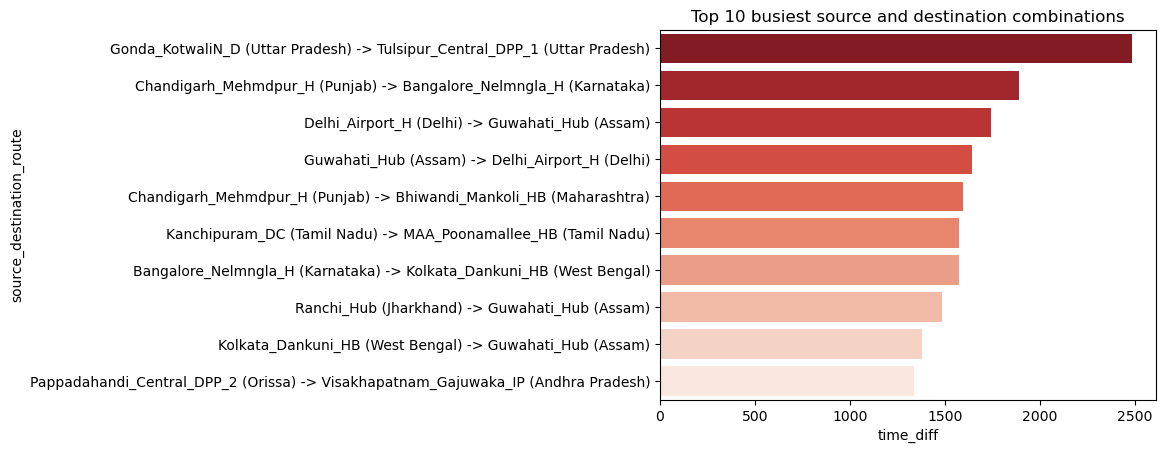

In [66]:
# Top 10 busiest source and destination combinations

source_destination_time_diff = df.groupby(['source_name', 'destination_name'])['time_diff'].median().sort_values(ascending=False).reset_index()[:10]

source_destination_time_diff['source_destination_route'] = source_destination_time_diff['source_name'] + ' -> '  + source_destination_time_diff['destination_name']
source_destination_time_diff[['source_destination_route', 'time_diff']]

sns.barplot(data=source_destination_time_diff, y='source_destination_route', x='time_diff', palette='Reds_r')
plt.title('Top 10 busiest source and destination combinations')
plt.show()

Gonda Kotwalin Uttar Pradesh -> Tulsipur Central Uttar Pradesh is the most busiest route with actual time quiet higher than project OSRM time.

## Insights

- The dataset carries trip details from **12 September 2018 to 8 October 2018**. A total of **14,787 trips** were conducted during this period.  

- **Segments** are intermediary trips that combine to form one complete trip. Segment trips are generally from **one warehouse to another**, or sometimes from a **warehouse to delivery points**.  

- Typically, segment delivery time is **below 700 minutes**, but due to **traffic congestion and other miscellaneous reasons**, delivery time can vary up to **4000 minutes**.  

- Usually, delivery distances are **less than 300 kilometers**; however, a few deliveries are made over **2000 kilometers**.  

- **Inter-state Full Truck Load (FTL) segments** take more delivery time, mainly due to **longer distances traveled and bulk orders**.  

- The **OSRM system fails to provide accurate estimates**, as actual time shows high variation, indicating strong **road dependency**.  

- After performing hypothesis testing, we can conclude that the **Open Source Routing Machine (OSRM)** does not provide accurate estimates for time and distance.  

- Drivers prefer traveling during the **night and early morning** due to **busy roads, traffic congestion, and business hours**.  

- The **average handling time for FTL shipments is higher** than for **carting shipments** due to **bulk orders**.  

- Most **inter-state deliveries are FTL**, whereas **intra-state deliveries are mixed**, with very high variation in delivery time.  

- Hypothesis testing shows that the **average speed for cart deliveries in inter-state and intra-state routes is significantly different**. However, in practical terms, the difference is **only about 1 km/h**.  

- The **average vehicle speed for cart deliveries during night and late evening is faster**. FTL shipment vehicle speed is normally around **35 km/h**, but decreases to **28 km/h during daytime**.  

- The most active delivery centers are **Gurgaon–Bilaspur, Bangalore–Nelamangala, and Bhiwandi–Mankoli**.  

- The **busiest route is Gonda Kotwali to Tulsipur Central**.  


---

## Recommendations

- The performance of the **Open Source Routing Machine (OSRM)** is poor as it does not provide accurate results when compared to actual time and distance. The business should consider working on **better OSRM models** to estimate delivery time and distance more accurately, considering **Indian road parameters**.  

- The **average speed for shipments in inter-state and intra-state deliveries is similar**, but inter-state average speed could potentially be **faster since most routes are highways**.  

- **More manpower or technology** can be deployed at busy centers such as **Gurgaon–Bilaspur, Bangalore–Nelamangala, and Bhiwandi–Mankoli**.  

- **Better vehicles** can be deployed for **carting shipments** to optimize delivery time.  

- Since there is strong **road dependency for deliveries**, **electric vehicles could be a better option** to reduce operational costs.